In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
df = pd.read_csv("USvideos.csv")

In [97]:
print("First 5 rows: \n")
print(df.head())

First 5 rows: 

      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   
3  puqaWrEC7tY      17.14.11   
4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE           CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...        LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...           Rudy Mancuso   
3                   Nickelback Lyrics: Real or Fake?  Good Mythical Morning   
4                           I Dare You: GOING BALD!?               nigahiga   

   category_id              publish_time  \
0           22  2017-11-13T17:13:01.000Z   
1           24  2017-11-13T07:30:00.000Z   
2           23  2017-11-12T19:05:24.000Z   
3           24  2017-11-13T11:00:04.000Z   
4           24  2017-11-12T18:01:41.000Z   

                                                tag

In [98]:
print("Statistical description of data: ")
print(df.describe())

Statistical description of data: 
        category_id         views         likes      dislikes  comment_count
count  24951.000000  2.495100e+04  2.495100e+04  2.495100e+04   2.495100e+04
mean      20.095187  1.343969e+06  4.698547e+04  2.815263e+03   5.954496e+03
std        7.585898  4.218125e+06  1.502137e+05  3.450366e+04   3.221468e+04
min        1.000000  5.490000e+02  0.000000e+00  0.000000e+00   0.000000e+00
25%       17.000000  1.282135e+05  2.598000e+03  1.150000e+02   3.545000e+02
50%       24.000000  3.803930e+05  1.074500e+04  3.790000e+02   1.165000e+03
75%       25.000000  1.120026e+06  3.258850e+04  1.233000e+03   3.655000e+03
max       43.000000  1.493761e+08  3.093544e+06  1.674420e+06   1.361580e+06


In [99]:
print(" info of data: ")
print(df.info())

 info of data: 
<class 'pandas.DataFrame'>
RangeIndex: 24951 entries, 0 to 24950
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   video_id                24951 non-null  str  
 1   trending_date           24951 non-null  str  
 2   title                   24951 non-null  str  
 3   channel_title           24951 non-null  str  
 4   category_id             24951 non-null  int64
 5   publish_time            24951 non-null  str  
 6   tags                    24951 non-null  str  
 7   views                   24951 non-null  int64
 8   likes                   24951 non-null  int64
 9   dislikes                24951 non-null  int64
 10  comment_count           24951 non-null  int64
 11  thumbnail_link          24951 non-null  str  
 12  comments_disabled       24951 non-null  bool 
 13  ratings_disabled        24951 non-null  bool 
 14  video_error_or_removed  24951 non-null  bool 
 15  description   

In [100]:
print("\nShape of data:")
print(df.shape)


Shape of data:
(24951, 16)


In [101]:
target_regression = "views"
#calculate top 25% quantile of views
viral_threshold = df["views"].quantile(0.75)
print("\nViral Threshold:",viral_threshold)




Viral Threshold: 1120025.5


In [102]:
#Create Classification target 
df["viral"] = (df["views"] > viral_threshold).astype(int)

In [103]:
# Viral column
print("\n Viral Column:")
print(df[["views","viral"]].head(10))


 Viral Column:
     views  viral
0   748374      0
1  2418783      1
2  3191434      1
3   343168      0
4  2095731      1
5   119180      0
6  2103417      1
7   817732      0
8   826059      0
9   256426      0



 Histograms of views:



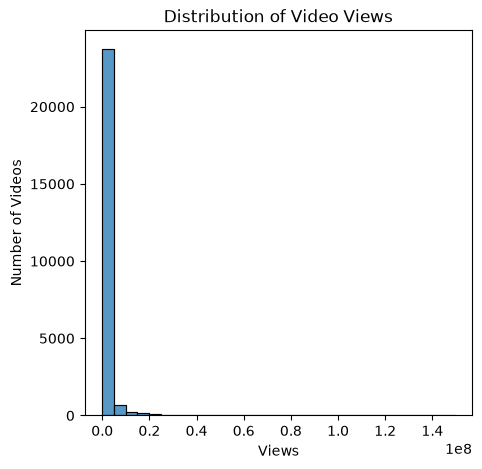

In [104]:
print("\n Histograms of views:\n")
plt.figure(figsize=(5,5))
sns.histplot(df["views"],bins=30)
plt.title("Distribution of Video Views")
plt.xlabel("Views")
plt.ylabel("Number of Videos")
plt.show()

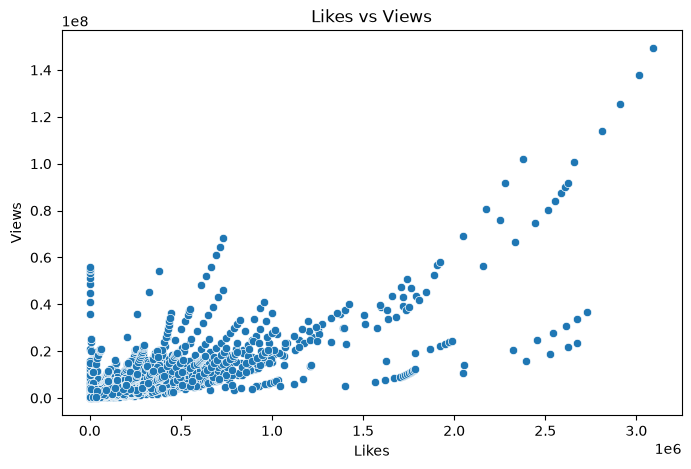

In [105]:
# Scatter plot Likes vs Views
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="likes", y="views")

plt.title("Likes vs Views")
plt.xlabel("Likes")
plt.ylabel("Views")

plt.show()

In [106]:
df["title_length"] = df["title"].str.len()


In [107]:
df["trending_date"] = pd.to_datetime(
    df["trending_date"],
    format="%y.%d.%m"
)

df["publish_time"] = pd.to_datetime(
    df["publish_time"],
    utc=True
)

df["days_since_publish"] = (
    df["trending_date"] -
    df["publish_time"].dt.tz_localize(None)
).dt.days

In [108]:
print(df.columns.tolist())

['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description', 'viral', 'title_length', 'days_since_publish']



Coorelation_matrix:
                        views     likes  dislikes  comment_count  title_length  \
views               1.000000  0.794761  0.512041       0.574644     -0.053863   
likes               0.794761  1.000000  0.446122       0.723176     -0.092561   
dislikes            0.512041  0.446122  1.000000       0.816315     -0.036133   
comment_count       0.574644  0.723176  0.816315       1.000000     -0.067864   
title_length       -0.053863 -0.092561 -0.036133      -0.067864      1.000000   
days_since_publish -0.026022 -0.027091 -0.007048      -0.016129     -0.065278   

                    days_since_publish  
views                        -0.026022  
likes                        -0.027091  
dislikes                     -0.007048  
comment_count                -0.016129  
title_length                 -0.065278  
days_since_publish            1.000000  


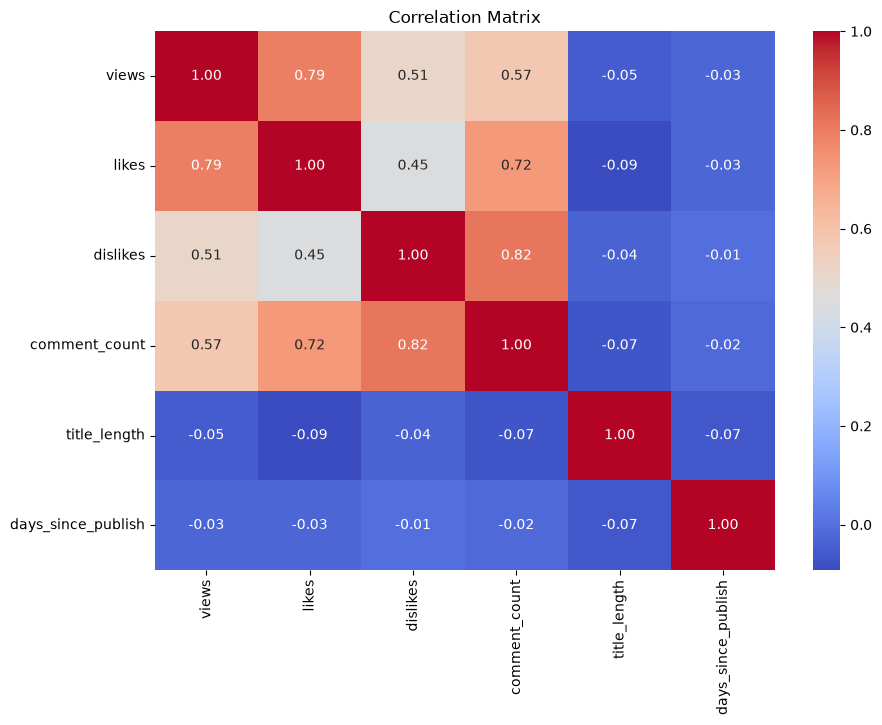

In [109]:
correlation_columns = [
    "views",
    "likes",
    "dislikes",
    "comment_count",
    "title_length",
    "days_since_publish"
]

correlation_matrix = df[correlation_columns].corr()

print("\nCoorelation_matrix:\n",correlation_matrix)
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [110]:
print("""Observations: Views have a strong positive correlation with likes(0.795)
indicating that videos with higher number of likes have higher number of views.
Moderate positive correlation comment_count(0.575) and dislikes(0.51).
Title length (-0.05) and days_since publish (-0.026) show very weak correlation
with views in this dataset.""")

Observations: Views have a strong positive correlation with likes(0.795)
indicating that videos with higher number of likes have higher number of views.
Moderate positive correlation comment_count(0.575) and dislikes(0.51).
Title length (-0.05) and days_since publish (-0.026) show very weak correlation
with views in this dataset.


# Hypothesis Testing
H₀: There is no significant difference in views between the high and low groups.

H₁: There is a significant difference in views between the high and low groups.

In [111]:
from scipy.stats import ttest_ind

In [112]:
#Split the videos into high and low groups using the median
likes_median = df["likes"].median()
dislikes_median = df["dislikes"].median()
comments_median =df["comment_count"].median()

#Likes vs Views
high_likes_views = df.loc[df["likes"] > likes_median,"views"]
low_likes_views = df.loc[df["likes"] <= likes_median,"views"]

likes_ttest = ttest_ind(
    high_likes_views,
    low_likes_views,
    equal_var = False
)

#Dislikes vs Views
high_dislikes_views = df.loc[df["dislikes"] >dislikes_median,"views"]
low_dislikes_views = df.loc[df["dislikes"] <= dislikes_median,"views"]

dislikes_ttest = ttest_ind(
    high_dislikes_views,
    low_dislikes_views,
    equal_var = False
)

# Comment Count vs Views
high_comments_views = df.loc[df["comment_count"] > comments_median, "views"]
low_comments_views = df.loc[df["comment_count"] <= comments_median, "views"]

comments_ttest = ttest_ind(
    high_comments_views,
    low_comments_views,
    equal_var=False
)


In [113]:
print("Hypothesis testing result")
print("-" * 40)
print("Likes vs Views")
print('t-statistic:',likes_ttest.statistic)
print('p-value',likes_ttest.pvalue)
print("\nDislikes vs Views")
print("t-statistic:",dislikes_ttest.statistic)
print("p-value:",dislikes_ttest.pvalue)

print("\nCommnet count vs views")
print("t-statistics:",comments_ttest.statistic)
print("p-value",comments_ttest.pvalue)

Hypothesis testing result
----------------------------------------
Likes vs Views
t-statistic: 39.89581679020387
p-value 0.0

Dislikes vs Views
t-statistic: 41.2568288529366
p-value: 0.0

Commnet count vs views
t-statistics: 38.76031078397242
p-value 0.0


In [114]:
alpha = 0.05

results = {
    "likes": likes_ttest.pvalue,
    "dislikes": dislikes_ttest.pvalue,
    "Comments": comments_ttest.pvalue
}
for feature,p_value in results.items():
    if p_value < alpha:
        print(f"{feature}: Reject H0 - statistically significant.")
    else:
         print(f"{feature}: Fail to reject H0 - not statistically significant.")

likes: Reject H0 - statistically significant.
dislikes: Reject H0 - statistically significant.
Comments: Reject H0 - statistically significant.


In [115]:
print("""The t-tests found statistically significant differences in views between the high and low groups for likes, 
      dislikes, and comment count.
      In each case, the high-engagement group had higher average views than the low-engagement group. 
      These results indicate an association between engagement metrics and views, but do not establish causation.""")

The t-tests found statistically significant differences in views between the high and low groups for likes, 
      dislikes, and comment count.
      In each case, the high-engagement group had higher average views than the low-engagement group. 
      These results indicate an association between engagement metrics and views, but do not establish causation.


# Preprocess Features


In [116]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical features
numeric_features = [
    "likes",
    "dislikes",
    "comment_count",
    "title_length",
    "days_since_publish"
]

# Categorical features
categorical_features = [
    "channel_title",
    "category_id"
]

# All input features
features = numeric_features + categorical_features

# Input data
X = df[features]

# Targets
y_reg = df["views"]
y_cls = df["viral"]

# Split into training and testing data
X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X,
    y_reg,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Fit on training data and transform it
X_train_processed = preprocessor.fit_transform(X_train)

# Only transform test data
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Original testing shape:", X_test.shape)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (19960, 7)
Original testing shape: (4991, 7)
Processed training shape: (19960, 1951)
Processed testing shape: (4991, 1951)


# Train linear regression model 

In [117]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train_processed, y_reg_train)

# Predict views for test data
y_pred = model.predict(X_test_processed)

# Calculate metrics
mse = mean_squared_error(y_reg_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_reg_test, y_pred)
r2 = r2_score(y_reg_test, y_pred)

print("Linear Regression Results")
print("-" * 30)
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

Linear Regression Results
------------------------------
MSE : 1903957983695.455
RMSE: 1379839.8398710827
MAE : 447216.7208954903
R²  : 0.9119939077936248


In [118]:
#feature coefficients
feature_names = preprocessor.get_feature_names_out()

coefficients = model.coef_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Absolute value helps identify strongest features
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("Top 15 Features:")
print(feature_importance.head(15))

Top 15 Features:
                                               Feature   Coefficient  \
852                    cat__channel_title_Kylie Jenner  4.860870e+07   
961                      cat__channel_title_MalumaVEVO  3.540158e+07   
1837                        cat__channel_title_ibighit -2.960736e+07   
427                    cat__channel_title_Desimpedidos -2.265515e+07   
915                cat__channel_title_Logan Paul Vlogs -1.992456e+07   
223                       cat__channel_title_Bud Light  1.352665e+07   
1261                     cat__channel_title_Ram Trucks  1.312438e+07   
440                    cat__channel_title_Disney•Pixar  1.253065e+07   
1651               cat__channel_title_Turkish Airlines  1.220548e+07   
705                          cat__channel_title_Intuit  1.040912e+07   
1719  cat__channel_title_Walt Disney Animation Studios  9.549560e+06   
746                            cat__channel_title_Jeep  9.539163e+06   
122                       cat__channel_title_BA

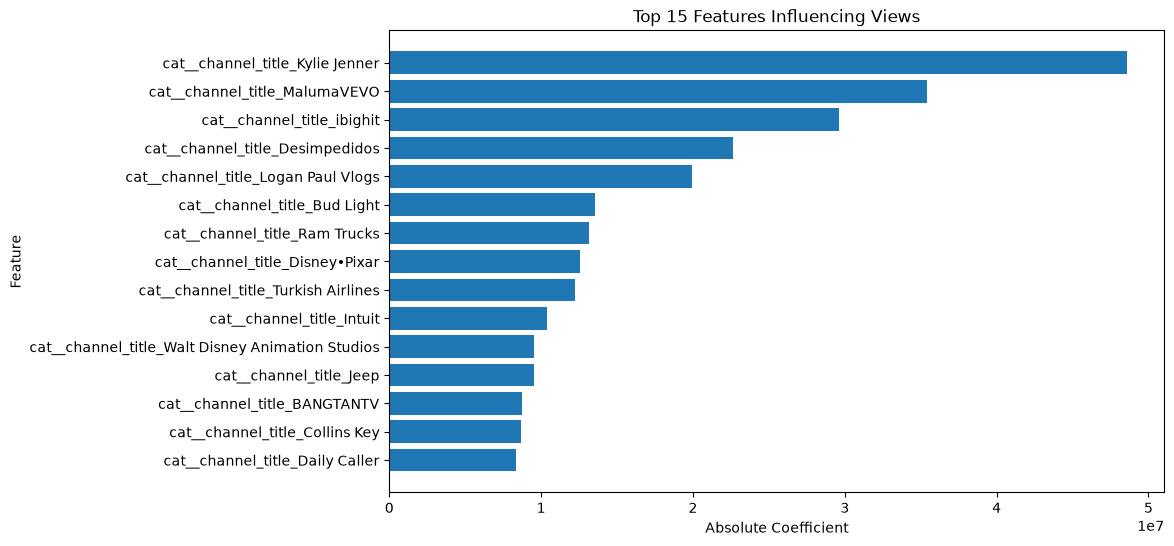

In [119]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Absolute_Coefficient"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Views")

plt.gca().invert_yaxis()

plt.show()

In [120]:
print("""Linear Regression was used to predict video views. The model was evaluated using MSE, RMSE, MAE and R². 
      The coefficient analysis shows which features have the strongest influence on predicted views.
      Features with larger absolute coefficients have greater influence, 
      while the sign of the coefficient indicates whether the relationship is positive or negative.""")

Linear Regression was used to predict video views. The model was evaluated using MSE, RMSE, MAE and R². 
      The coefficient analysis shows which features have the strongest influence on predicted views.
      Features with larger absolute coefficients have greater influence, 
      while the sign of the coefficient indicates whether the relationship is positive or negative.


# Task 6 . Logistic Regression

In [121]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train_processed, y_cls_train)

# Predict 0 or 1
y_cls_pred = log_model.predict(X_test_processed)

# Predict probability of being viral
y_cls_prob = log_model.predict_proba(X_test_processed)[:, 1]

In [122]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_cls_test, y_cls_pred)
precision = precision_score(y_cls_test, y_cls_pred)
recall = recall_score(y_cls_test, y_cls_pred)
f1 = f1_score(y_cls_test, y_cls_pred)
roc_auc = roc_auc_score(y_cls_test, y_cls_prob)

print("Logistic Regression Results")
print("-" * 35)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

Logistic Regression Results
-----------------------------------
Accuracy : 0.9380885594069325
Precision: 0.9195710455764075
Recall   : 0.8245192307692307
F1-score : 0.8694550063371356
ROC-AUC  : 0.9819316570418628


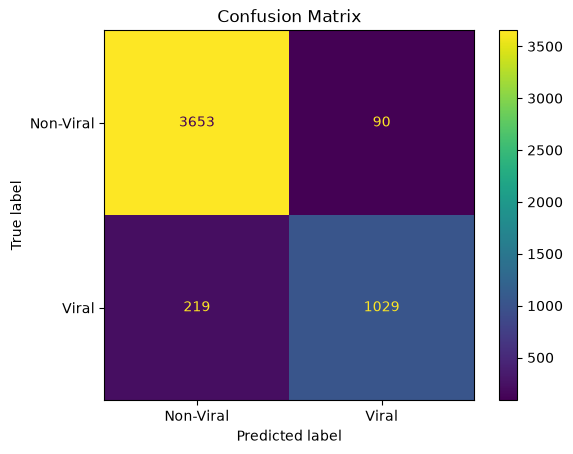

In [123]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_cls_test, y_cls_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Viral", "Viral"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

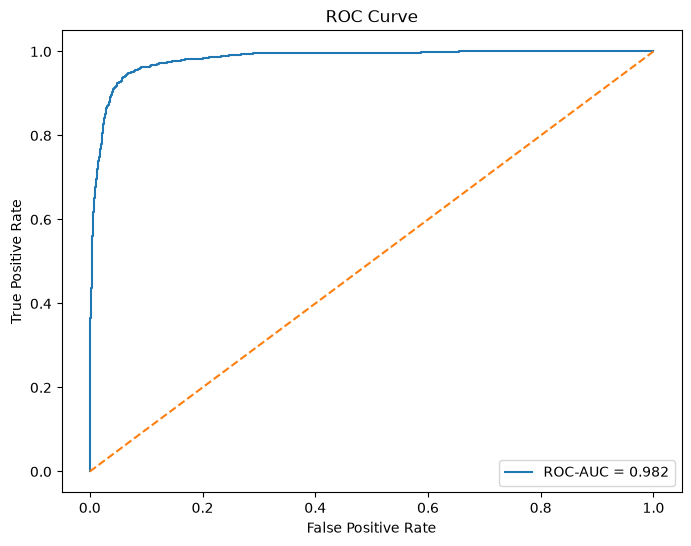

In [124]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_cls_test,
    y_cls_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [125]:
feature_names = preprocessor.get_feature_names_out()

log_coefficients = log_model.coef_[0]

log_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_coefficients
})

log_feature_importance["Absolute_Coefficient"] = (
    log_feature_importance["Coefficient"].abs()
)

log_feature_importance = log_feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("Top 15 Features Influencing Virality:")
print(log_feature_importance.head(15))

Top 15 Features Influencing Virality:
                                      Feature  Coefficient  \
0                                  num__likes    10.624221   
1                               num__dislikes     6.234195   
1307  cat__channel_title_Roy Moore for Senate    -4.725834   
852           cat__channel_title_Kylie Jenner     4.638466   
1404              cat__channel_title_Snapchat     4.410147   
1119        cat__channel_title_NiallHoranVEVO    -4.179453   
672                   cat__channel_title_Hulu     3.960488   
1053   cat__channel_title_Movieclips Trailers    -3.863045   
272         cat__channel_title_Camila Cabello    -3.606188   
14         cat__channel_title_5-Minute Crafts     3.480445   
553            cat__channel_title_Foot Locker     3.425285   
965              cat__channel_title_Manny Mua    -3.413710   
489         cat__channel_title_ElleOfTheMills    -3.363532   
550         cat__channel_title_Focus Features     3.333765   
618                cat__channel_

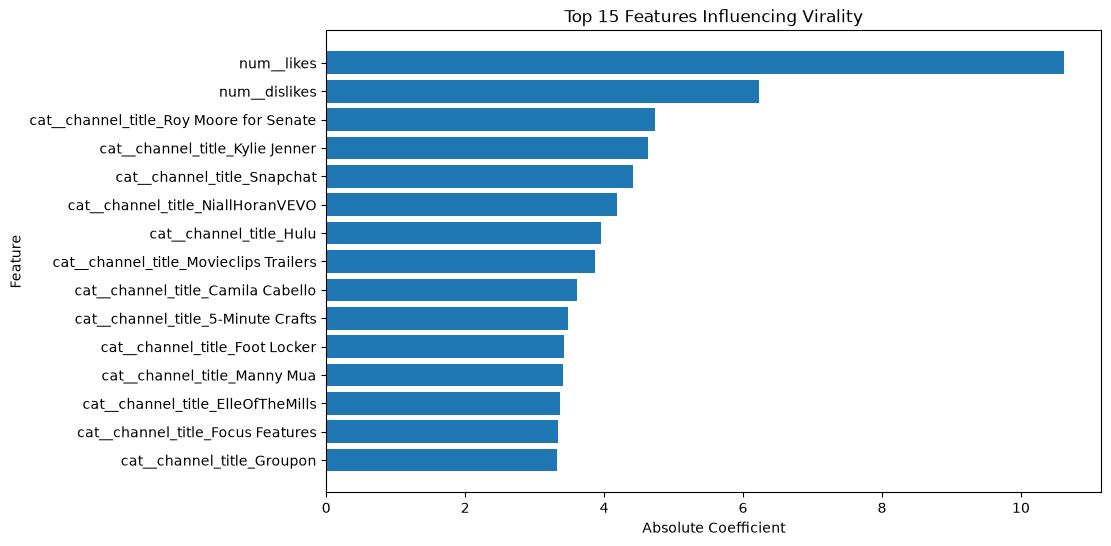

In [126]:
# Features importance plot
top_features = log_feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Absolute_Coefficient"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Virality")

plt.gca().invert_yaxis()

plt.show()


In [127]:
print("""The Logistic Regression model was evaluated using accuracy, precision, 
      , F1-score and ROC-AUC. The coefficient analysis shows that [feature names] 
      had the strongest influence on the prediction of video virality.
      Positive coefficients indicate an association with higher viral probability,
      while negative coefficients indicate an association with lower viral probability. """)

The Logistic Regression model was evaluated using accuracy, precision, 
      , F1-score and ROC-AUC. The coefficient analysis shows that [feature names] 
      had the strongest influence on the prediction of video virality.
      Positive coefficients indicate an association with higher viral probability,
      while negative coefficients indicate an association with lower viral probability. 


# Task 7 Cross Validation and Scaling Comparison

In [128]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# Linear Regression model
cv_linear_model = LinearRegression()

# 5-fold cross-validation
linear_scores = cross_val_score(
    cv_linear_model,
    X_train_processed,
    y_reg_train,
    cv=5,
    scoring="r2"
)

print("Linear Regression - 5 Fold Cross-Validation")
print("Scores:", linear_scores)
print("Mean R²:", linear_scores.mean())
print("Variance:", linear_scores.var())

Linear Regression - 5 Fold Cross-Validation
Scores: [0.906319   0.90757932 0.88369804 0.84551133 0.91283052]
Mean R²: 0.8911876414193207
Variance: 0.0006216957412632457


In [129]:
# Logistic Regression Cross Validation 
from sklearn.linear_model import LogisticRegression

# Logistic Regression model
cv_log_model = LogisticRegression(max_iter=1000)

# 5-fold cross-validation
logistic_scores = cross_val_score(
    cv_log_model,
    X_train_processed,
    y_cls_train,
    cv=5,
    scoring="roc_auc"
)

print("\nLogistic Regression - 5 Fold Cross-Validation")
print("Scores:", logistic_scores)
print("Mean ROC-AUC:", logistic_scores.mean())
print("Variance:", logistic_scores.var())


Logistic Regression - 5 Fold Cross-Validation
Scores: [0.9824482  0.9824482  0.97982304 0.98033408 0.98226212]
Mean ROC-AUC: 0.9814631266541098
Variance: 1.3087484685330979e-06


In [130]:
# Create Min max version 
from sklearn.preprocessing import MinMaxScaler

minmax_preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_minmax = minmax_preprocessor.fit_transform(X_train)
X_test_minmax = minmax_preprocessor.transform(X_test)

In [131]:
# Compare logistic Regression 
# Logistic Regression with MinMaxScaler
minmax_log_model = LogisticRegression(max_iter=1000)

minmax_scores = cross_val_score(
    minmax_log_model,
    X_train_minmax,
    y_cls_train,
    cv=5,
    scoring="roc_auc"
)

print("Scaling Comparison")
print("-" * 30)

print("StandardScaler")
print("Mean ROC-AUC:", logistic_scores.mean())
print("Variance:", logistic_scores.var())

print("\nMinMaxScaler")
print("Mean ROC-AUC:", minmax_scores.mean())
print("Variance:", minmax_scores.var())

Scaling Comparison
------------------------------
StandardScaler
Mean ROC-AUC: 0.9814631266541098
Variance: 1.3087484685330979e-06

MinMaxScaler
Mean ROC-AUC: 0.9503627830142584
Variance: 2.7294395576546796e-05


In [132]:
# Logistic Regression Feature importance 
final_log_model = LogisticRegression(max_iter=1000)

final_log_model.fit(
    X_train_processed,
    y_cls_train
)

feature_names = preprocessor.get_feature_names_out()

coefficients = final_log_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("Top 15 Features Influencing Virality:")
print(feature_importance.head(15))

Top 15 Features Influencing Virality:
                                      Feature  Coefficient  \
0                                  num__likes    10.624221   
1                               num__dislikes     6.234195   
1307  cat__channel_title_Roy Moore for Senate    -4.725834   
852           cat__channel_title_Kylie Jenner     4.638466   
1404              cat__channel_title_Snapchat     4.410147   
1119        cat__channel_title_NiallHoranVEVO    -4.179453   
672                   cat__channel_title_Hulu     3.960488   
1053   cat__channel_title_Movieclips Trailers    -3.863045   
272         cat__channel_title_Camila Cabello    -3.606188   
14         cat__channel_title_5-Minute Crafts     3.480445   
553            cat__channel_title_Foot Locker     3.425285   
965              cat__channel_title_Manny Mua    -3.413710   
489         cat__channel_title_ElleOfTheMills    -3.363532   
550         cat__channel_title_Focus Features     3.333765   
618                cat__channel_

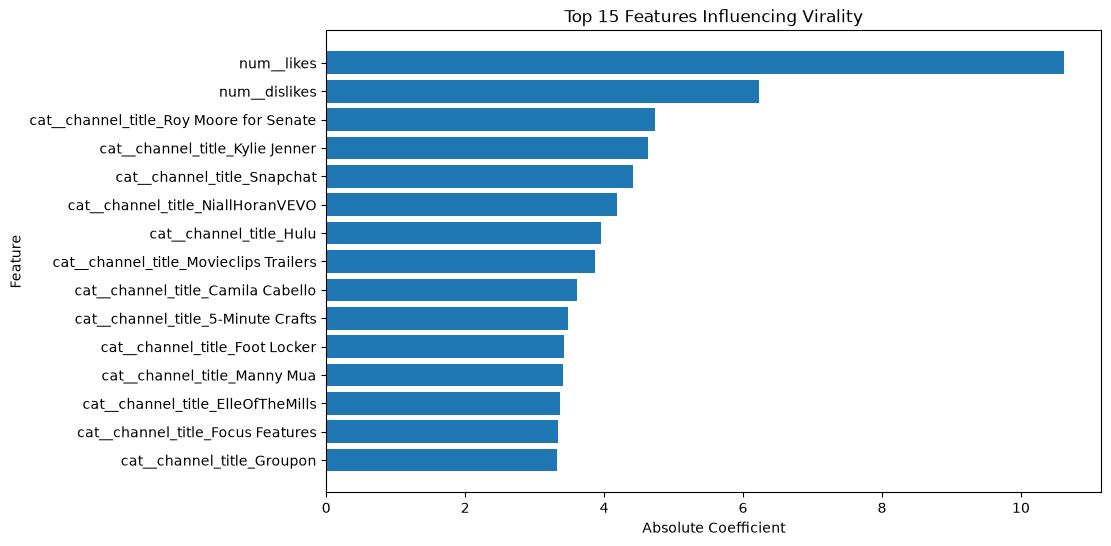

In [133]:
# Plot 
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Absolute_Coefficient"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Virality")

plt.gca().invert_yaxis()

plt.show()

In [134]:
print("""Interprepation - 
      Positive coefficient → higher probability of viral
      Negative coefficient → lower probability of viral
      Large absolute value → stronger influence """)

Interprepation - 
      Positive coefficient → higher probability of viral
      Negative coefficient → lower probability of viral
      Large absolute value → stronger influence 


# Reports and insights

In [135]:


print("=" * 60)
print("YOUTUBE ANALYTICS - FINAL REPORT")
print("=" * 60)


# 1. DATASET SUMMARY
# --------------------------------------------------

print("\n1. DATASET SUMMARY")
print("-" * 40)

print("Total videos:", len(df))
print("Viral threshold:", viral_threshold)

print("\nViral distribution:")
print(df["viral"].value_counts())


# 2. REGRESSION MODEL PERFORMANCE
# --------------------------------------------------

print("\n2. REGRESSION MODEL PERFORMANCE")
print("-" * 40)

print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

print("\nTop predictors of views:")

print(
    feature_importance[
        ["Feature", "Coefficient"]
    ].head(10)
)

# 3. CLASSIFICATION MODEL PERFORMANCE
# --------------------------------------------------

print("\n3. CLASSIFICATION MODEL PERFORMANCE")
print("-" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nTop predictors of viral videos:")

print(
    log_feature_importance[
        ["Feature", "Coefficient"]
    ].head(10)
)


# 4. HYPOTHESIS TESTING
# --------------------------------------------------

print("\n4. HYPOTHESIS TESTING")
print("-" * 40)

print("Likes p-value:", likes_ttest.pvalue)
print("Dislikes p-value:", dislikes_ttest.pvalue)
print("Comment count p-value:", comments_ttest.pvalue)

print("\nGroup mean comparisons:")

print(
    "High likes mean views:",
    high_likes_views.mean()
)

print(
    "Low likes mean views:",
    low_likes_views.mean()
)

print(
    "High dislikes mean views:",
    high_dislikes_views.mean()
)

print(
    "Low dislikes mean views:",
    low_dislikes_views.mean()
)

print(
    "High comments mean views:",
    high_comments_views.mean()
)

print(
    "Low comments mean views:",
    low_comments_views.mean()
)

# 5. CROSS-VALIDATION
# --------------------------------------------------

print("\n5. CROSS-VALIDATION")
print("-" * 40)

print(
    "Linear Regression Mean R²:",
    linear_scores.mean()
)

print(
    "Linear Regression Variance:",
    linear_scores.var()
)

print(
    "Logistic Regression Mean ROC-AUC:",
    logistic_scores.mean()
)

print(
    "Logistic Regression Variance:",
    logistic_scores.var()
)

print(
    "MinMax Logistic Mean ROC-AUC:",
    minmax_scores.mean()
)

print(
    "MinMax Logistic Variance:",
    minmax_scores.var()
)



# 6. BUSINESS INSIGHTS
# --------------------------------------------------

print("\n6. BUSINESS INSIGHTS")
print("-" * 40)

print("""
1. Engagement:
   Likes, dislikes and comments show statistically significant
   differences in views between their high and low groups.

2. Video content:
   The regression and classification coefficients can be used
   to identify the features most strongly associated with views
   and viral classification.

3. Video length:
   Title length is included as a feature. Its coefficient should
   be checked before making recommendations about optimal length.

4. Viral prediction:
   Logistic Regression can help identify videos with a higher
   probability of becoming viral.

5. Content strategy:
   Creators should focus on increasing meaningful audience
   engagement through relevant and engaging content.

6. Model validation:
   Cross-validation helps determine whether model performance
   is consistent across different subsets of the data.
""")

YOUTUBE ANALYTICS - FINAL REPORT

1. DATASET SUMMARY
----------------------------------------
Total videos: 24951
Viral threshold: 1120025.5

Viral distribution:
viral
0    18713
1     6238
Name: count, dtype: int64

2. REGRESSION MODEL PERFORMANCE
----------------------------------------
MSE  : 1903957983695.46
RMSE : 1379839.84
MAE  : 447216.72
R²   : 0.9120

Top predictors of views:
                                      Feature  Coefficient
0                                  num__likes    10.624221
1                               num__dislikes     6.234195
1307  cat__channel_title_Roy Moore for Senate    -4.725834
852           cat__channel_title_Kylie Jenner     4.638466
1404              cat__channel_title_Snapchat     4.410147
1119        cat__channel_title_NiallHoranVEVO    -4.179453
672                   cat__channel_title_Hulu     3.960488
1053   cat__channel_title_Movieclips Trailers    -3.863045
272         cat__channel_title_Camila Cabello    -3.606188
14         cat__chann